This is where I experiment with features.

In [ ]:
%load_ext line_profiler
%load_ext memory_profiler

In [ ]:
%matplotlib widget

In [1]:
from src.nn.script import learning, load_object, MultilayerPerceptron, cost, accuracy, cost_gradient, vectorize_learning_set
from src.dataset_reader.dataset_reader import load_dataset
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import axes3d
import random
from copy import deepcopy
from timeit import timeit
import tqdm
mlp = MultilayerPerceptron(layout=[784, 16, 16, 10], dtype=np.float64)
training_set, test_set = load_dataset(training_size=60000, old_format=True)
training_costs, accuracies, gradients_norms, consecutive_gradients_cosines = [], [], [], []

In [2]:
training_set = vectorize_learning_set(learning_set=training_set, max_batch_size=10)

In [3]:
tracked_metrics = learning(mlp=mlp, training_set=training_set, test_set=test_set, eta=2*1e-03, step_count=50, metrics_to_track=["training_costs", "accuracies", "gradients_norms", "consecutive_gradients_cosines"])
training_costs += tracked_metrics["training_costs"]
accuracies += tracked_metrics["accuracies"]
gradients_norms += tracked_metrics["gradients_norms"]
consecutive_gradients_cosines += tracked_metrics["consecutive_gradients_cosines"]

100%|██████████| 50/50 [01:35<00:00,  1.91s/it]


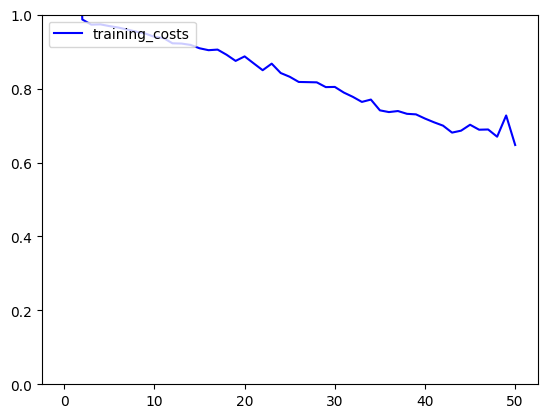

In [4]:
plt.close()
fig, ax1 = plt.subplots()

ax1.plot(training_costs[:], label="training_costs", color="blue")
ax1.legend(loc = "upper left")
ax1.set_ylim(0,1)
"""
ax2 = ax1.twinx()
ax2.plot(consecutive_gradients_cosines[0:], label="previous_cosines", color="red")
ax2.legend(loc="upper right")
ax2.set_ylim([-1,1])

ax3 = ax2.twinx()
ax3.plot(gradients_norms[0:], label="previous_gradients_norms", color="purple")
ax3.legend(loc = "lower left")"""

plt.show()

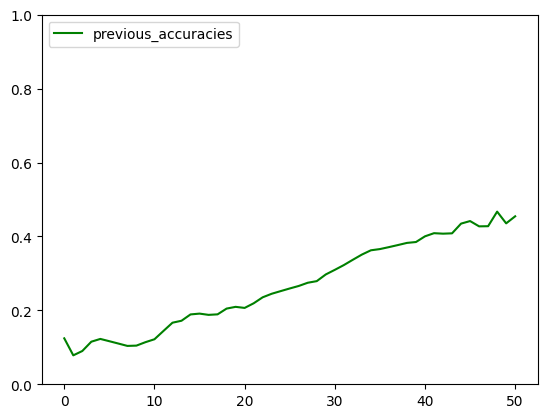

In [5]:
fig, ax1 = plt.subplots()

ax1.plot(accuracies[:], label="previous_accuracies", color="green")
ax1.legend(loc = "upper left")
ax1.set_ylim([0,1])
"""
ax2 = ax1.twinx()
ax2.plot(previous_cosines[0:], label="previous_cosines", color="red")
ax2.legend(loc="upper right")
ax2.set_ylim([-1,1])

ax3 = ax1.twinx()
ax3.plot(previous_gradient_norms[3:], label="previous_gradient_norms", color="purple")
ax3.legend(loc = "lower left")"""

plt.show()

## 1st experiment : Are training_cost and accuracy smooth at the scales uf the current prefered learning step (eta = 8*1e-03) ?##

In [ ]:
print(cost(multilayer_perceptron=multilayer_perceptron, training_set=training_set))
print(accuracy(multilayer_perceptron=multilayer_perceptron, test_set=test_set))

In [ ]:
in_between_costs = []
in_between_accuracies = []
eta = 1.3 * 1e-03
_training_set = random.choices(population=training_set, k=1000)
_cost_gradient = cost_gradient(
        multilayer_perceptron=multilayer_perceptron, training_set=_training_set
    )
N = len(multilayer_perceptron.layers)
layout = multilayer_perceptron.layout
nb_in_between_stops = 10
nudge = 1 / nb_in_between_stops

for _ in range(nb_in_between_stops+1):
    # modif. of the parameters
    for i in range(N):
        for variable in range(2):
            multilayer_perceptron.variables[i][variable] += (
                - nudge * eta * np.average(layout) * _cost_gradient[i][variable]
            )
            
    training_cost = cost(multilayer_perceptron=multilayer_perceptron, training_set=_training_set)
    in_between_costs.append(training_cost)
    _accuracy = accuracy(multilayer_perceptron=multilayer_perceptron, test_set=test_set)
    in_between_accuracies.append(_accuracy)

training_costs.append(in_between_costs[-1])
accuracies.append(in_between_accuracies[-1])
    

In [ ]:
fig1, ax1 = plt.subplots()

ax1.plot(in_between_costs, label="in_between_costs", color="blue")
ax1.legend(loc="upper right")
#ax1.set_ylim([0.4,0.6])

ax2 = ax1.twinx()
ax2.plot(in_between_accuracies, label="in_between_accuracies", color="green")
ax2.legend(loc="upper left")
#ax2.set_ylim([0.6,0.7])

plt.plot()

## 2nd experiment : Adding inertia ##
I'm going to compare the same mlp with and without inertia. First one by one, to get an intuition of it. Then, maybe later, I'll verify it by computing statistics on a lot of examples. 

In [ ]:
training_costs_with_inertia, accuracies_with_inertia = [], []
training_costs_with_inertia_2, accuracies_with_inertia_2 = [], []
multilayer_perceptron_with_inertia = deepcopy(multilayer_perceptron)
multilayer_perceptron_with_inertia_2 = deepcopy(multilayer_perceptron)

In [ ]:
_steps_number=400
eta = 2*1e-03
tracked_metrics = learning(multilayer_perceptron=multilayer_perceptron, training_set=training_set, test_set=test_set, eta=eta, steps_number=_steps_number, inertia=False, metrics_to_track=["training_costs", "accuracies"])
training_costs += tracked_metrics["training_costs"]
accuracies += tracked_metrics["accuracies"]
tracked_metrics_with_inertia = learning(multilayer_perceptron=multilayer_perceptron_with_inertia, training_set=training_set, test_set=test_set, eta=eta, steps_number=_steps_number, inertia_strength=0.3, metrics_to_track=["training_costs", "accuracies"])
training_costs_with_inertia += tracked_metrics_with_inertia["training_costs"]
accuracies_with_inertia += tracked_metrics_with_inertia["accuracies"]
tracked_metrics_with_inertia_2 = learning(multilayer_perceptron=multilayer_perceptron_with_inertia_2, training_set=training_set, test_set=test_set, eta=eta, steps_number=_steps_number, inertia_strength=0.6, metrics_to_track=["training_costs", "accuracies"])
training_costs_with_inertia_2 += tracked_metrics_with_inertia_2["training_costs"]
accuracies_with_inertia_2 += tracked_metrics_with_inertia_2["accuracies"]

In [ ]:
fig1, ax1 = plt.subplots()

ax1.plot(training_costs, label="training_costs", color="violet")
ax1.legend(loc="upper left")
ax1.set_ylim([0,1])

ax1.plot(training_costs_with_inertia, label="//_with_inertia (inertia_strength=0.3)", color="blue")

ax1.plot(training_costs_with_inertia_2, label="//_with_inertia (inertia_strength=0.6)", color="cyan")


plt.title("eta=2*1e-03 up until 400, exp. n°3")
plt.show()

In [ ]:
fig1, ax1 = plt.subplots()

ax1.plot(accuracies[:], label="accuracies", color="lime")
ax1.legend(loc="upper left")
ax1.set_ylim([0,1])

ax1.plot(accuracies_with_inertia[:], label="//_with_inertia (inertia_strength=0.3)", color="darkgreen")

ax1.plot(accuracies_with_inertia_2[:], label="//_with_inertia (inertia_strengthen=0.6)", color="yellow")

plt.title("eta=2*1e-03 up until 400, exp. n°3")
plt.show()

In [ ]:
print(np.average(accuracies[-110:-100]))
print(np.average(accuracies[-10:]))
print(np.average(accuracies_with_inertia[-110:-100]))
print(np.average(accuracies_with_inertia[-10:]))
print(np.average(accuracies_with_inertia_2[-110:-100]))
print(np.average(accuracies_with_inertia_2[-10:]))

## 3rd experiment : Vectorizing the learning sets in batches ##
Let's compare the speed of accuracy() with and without vectorization of the test set.


In [ ]:
batch_sizes = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
times_taken = []
for batch_size in batch_sizes:
    vectorized_test_set = vectorize_learning_set(learning_set=test_set, max_batch_size=batch_size)
    times_taken.append(timeit(stmt="accuracy(multilayer_perceptron=multilayer_perceptron, test_set=vectorized_test_set)", number=10, globals=globals()))

In [ ]:
plt.scatter(x=batch_sizes, y=times_taken)
plt.title(label="Accuracy() time vs batch size")
plt.show()

In [ ]:
batch_sizes = [1,4500, 5000, 5500, 6000]
times_taken = []
for batch_size in batch_sizes:
    vectorized_test_set = vectorize_learning_set(learning_set=test_set, max_batch_size=batch_size)
    times_taken.append(timeit(stmt="accuracy(multilayer_perceptron=multilayer_perceptron, test_set=vectorized_test_set)", number=100, globals=globals()))

In [ ]:
times_taken

Ccl : sur ma machine, il semblerait que la batch_size optimale pour calculer l'accuracy d'un mlp (784-16-16-10) (et avec tous les paramètres que j'ai fixés : le fait qu'il soit fully connected, that relu and the sigmoid are used) soit 5000. The computation is accelerated by a 175 factor between batch_size = 1 and batch_size = optimal_batch_size ! It was worth it.

In [ ]:
multilayer_perceptron_copy = deepcopy(multilayer_perceptron)
vectorized_test_set = vectorize_learning_set(learning_set=test_set, max_batch_size=5000)
print(timeit(stmt="learning(multilayer_perceptron=multilayer_perceptron, training_set=training_set, eta=4*1e-03, steps_number=100, metrics_to_track=[\"accuracies\"], test_set = vectorized_test_set)", number=1, globals=globals()))
print(timeit(stmt="learning(multilayer_perceptron=multilayer_perceptron_copy, training_set=training_set, eta=4*1e-03, steps_number=100, metrics_to_track=[\"accuracies\"], test_set=test_set)", number=1, globals=globals()))

In [ ]:
print(accuracy(multilayer_perceptron=multilayer_perceptron, test_set=vectorized_test_set))
print(accuracy(multilayer_perceptron=multilayer_perceptron_copy, test_set=vectorized_test_set))

Funny, not eaxctly the same. I don't see why. I don't think it comes from my code ? Actually I think I know. I'll fix it later.

In [ ]:
vectorized_test_set = vectorize_learning_set(learning_set=test_set, max_batch_size=5000)
%lprun -f learning tracked_metrics = learning(multilayer_perceptron=multilayer_perceptron, training_set=training_set, eta=4*1e-03, metrics_to_track=["training_costs", "accuracies"], test_set=vectorized_test_set, steps_number=100)
training_costs += tracked_metrics["training_costs"]
accuracies += tracked_metrics["accuracies"]

In [ ]:
vectorized_training_set = vectorize_learning_set(learning_set=training_set[:10000], max_batch_size=5000)
print(timeit("stmt=cost(multilayer_perceptron=multilayer_perceptron, training_set=vectorized_training_set)", number=10, globals=globals()))
print(timeit("stmt=cost(multilayer_perceptron=multilayer_perceptron, training_set=training_set[:10000])", number=10, globals=globals()))

In [ ]:
max_batch_sizes = [900, 1000, 2000, 3000, 4000, 5000]
times_taken = []
for max_batch_size in max_batch_sizes:
    vectorized_training_set = vectorize_learning_set(learning_set=training_set[0:60000], max_batch_size=max_batch_size)
    times_taken.append(timeit(stmt="cost(multilayer_perceptron=multilayer_perceptron, training_set=vectorized_training_set)", number=10, globals=globals()))
plt.plot(times_taken)

In [ ]:
times_taken

In [ ]:
vectorized_training_set = vectorize_learning_set(learning_set=training_set[:1000], max_batch_size=7)
print(cost(multilayer_perceptron=multilayer_perceptron, training_set=training_set[:1000]))
print(cost(multilayer_perceptron=multilayer_perceptron, training_set=vectorized_training_set))

pas tout à fait égal non plus. Je ne vois pas prq.

## Vectorization of cost_gradient_one_batch
There're many ways to compute the partial derivative of the cost of the batch w.r.t to the weights of one layer :
1 - in comprehension with @
2 - einseisum, with or without path
3 - tensordot and then selecting only the pertinent rows
4 - point-wise product
5 - the other method with an output (a_1*B, a_2*B, a_3*B)

I want the best method asymptotically, even if it is not the best with the matrices manipulated for the hand_written digit classification task.

# Correctness of the algorithms

In [ ]:
%%writefile benchmarks_methods.py

batch_size = 3
len_layer_i = 2
len_layer_i_1 = 4
D = np.array([[1, 4], [2, 5], [3, 6]])
A = np.array([[ 1,  2,  3,  4], [ 5,  6,  7,  8], [ 9, 10, 11, 12]])
correct_output = np.array(
[
    [
        [1,  2,  3,  4], 
        [4, 8, 12, 16],
    ],
    [
        [10, 12, 14, 16],
        [25, 30, 35, 40],
    ],
    [
        [27, 30, 33, 36],
        [54, 60, 66, 72],
    ],
]
)
# 1 - In comprehension with @
def method_1(D, A):
    return np.array([np.atleast_2d(D[s]).T @ np.atleast_2d(A[s]) for s in range(A.shape[0])])
output_comprehension = method_1(D, A)
np.testing.assert_array_equal(x=output_comprehension, y=correct_output)
# 2 - Einstein sum
def method_2_no_optimization(D, A):
    return np.einsum('js,sk->sjk', D.T, A)
output_einsum_no_optimization = method_2_no_optimization(D, A)
np.testing.assert_array_equal(x=output_einsum_no_optimization, y=correct_output)
def method_2_greedy(D, A):
    return np.einsum('js,sk->sjk', D.T, A, optimize="greedy")
output_einsum_greedy = method_2_greedy(D, A)
np.testing.assert_array_equal(x=output_einsum_greedy, y=correct_output)
_PATH = np.einsum_path('js,sk->sjk', D.T, A, optimize="optimal")[0]
def method_2_optimal_with_path(D, A):
    return np.einsum('js,sk->sjk', D.T, A, optimize=_PATH)
output_einsum_optimal_with_path = method_2_optimal_with_path(D, A)
np.testing.assert_array_equal(x=output_einsum_optimal_with_path, y=correct_output)
# 3 - tensordot, and then selecting only the pertinent rows
def method_3(D, A):
    D_expanded = np.expand_dims(a=D, axis=2)
    A_expanded = np.expand_dims(a=A, axis=1)
    full_result = np.tensordot(a=D_expanded, b=A_expanded, axes=([2], [1]))
    output_tensordot = np.array([[full_result[s][k][s] for k in range(len_layer_i)] for s in range(batch_size)])
    return output_tensordot
output_tensordot = method_3(D, A)
np.testing.assert_array_equal(x=output_tensordot, y=correct_output)
def method_3_bis(D, A):
    # Special rotation
    batch_size = D.shape[0]
    len_layer_i = D.shape[1]
    len_layer_i_1 = A.shape[1]
    D_rot = np.reshape(a=D, newshape=(batch_size, len_layer_i, 1))
    A_rot = np.reshape(a=A, newshape=(batch_size, 1, len_layer_i_1))
    _output = np.matmul(D_rot, A_rot)
    return _output
output_dot = method_3_bis(D, A)
np.testing.assert_array_equal(x=output_dot, y=output_tensordot)
# 4 - Point-wise product of two previously constructed matrices (taking advantage of the fact 
# that each term of the final matrix is only a product)
def method_4(D, A):
    # Special rotation
    batch_size = D.shape[0]
    len_layer_i = D.shape[1]
    len_layer_i_1 = A.shape[1]
    D_rot = np.reshape(a=D, newshape=(batch_size, len_layer_i, 1))
    A_rot = np.reshape(a=A, newshape=(batch_size, 1, len_layer_i_1))
    
    D_expanded = np.tile(A=D_rot, reps=[1, 1, len_layer_i_1])
    A_expanded = np.tile(A=A_rot, reps=[1, len_layer_i, 1])
    return D_expanded * A_expanded
output_point_wise = method_4(D, A)
np.testing.assert_array_equal(x=output_point_wise, y=correct_output)

In [ ]:
D_rot = np.reshape(a=D, newshape=(batch_size, len_layer_i, 1))
A_rot = np.reshape(a=A, newshape=(batch_size, 1, len_layer_i_1))
print(np.matmul(D_rot, A_rot))

# Benchmark

In [ ]:
nb_examples = 100
size_layer_i = 100
size_layer_i_1 = 110
D = np.random.rand(nb_examples, size_layer_i)
A = np.random.rand(nb_examples, size_layer_i_1)

# 1 - In comprehension with @
time_taken = timeit(stmt="method_1(D, A)", number=1000, globals=globals())
print(f"In comprehension with @: {time_taken}")
# remarque : c'est 20 fois plus rapide que si D et A étaient des listes d'arrays (j'ai fait le test)
# 2 - Einsum
time_taken = timeit(stmt="method_2_no_optimization(D, A)", number=1000, globals=globals())
print(f"Einsum no optimization: {time_taken}")
time_taken = timeit(stmt="method_2_greedy(D, A)", number=1000, globals=globals())
print(f"Einsum greedy optimization: {time_taken}")
_PATH = np.einsum_path('js,sk->sjk', D.T, A, optimize="optimal")[0]
time_taken = timeit(stmt="method_2_optimal_with_path(D, A)", number=1000, globals=globals())
print(f"Einsum optimal optimization computed previously: {time_taken}")
# 3 - Tensordot (maybe a better way) and selecting only the pertinent rows  
time_taken = timeit(stmt="method_3_bis(D, A)", number=1000, globals=globals())
print(f"Matmul of prepared matrices: {time_taken}")
# 4 - Pointwise multiplication of previously padded matrice
time_taken = timeit(stmt="method_4(D, A)", number=1000, globals=globals())
print(f"Pointwise multiplication of previously padded matrices {time_taken}")


In [ ]:
from benchmarks_methods import method_3_bis, method_1, method_4, method_2_greedy
_layer_size = 100
_batch_size = 1000
A = np.random.rand(_batch_size, _layer_size)
D = np.random.rand(_batch_size, _layer_size)
%mprun -f method_2_greedy _time_taken = timeit(stmt="method_2_greedy(D, A)", number=1, globals=globals())

In [ ]:
D = np.array([[1, 4], [2, 5], [3, 6]])

D_rot = np.reshape(a=D.T, newshape=(3, 2, 1))
print(D_rot)
# Bonne dimensions mais les nombres ne vont plus ensemble, pourtant c'était l'opération que j'avais naturellement en tête.

D_rot_2 = np.reshape(a=D, newshape=(3,2,1))
print(D_rot_2)
# C'est cette opération la bonne. J'ajouterai un schéma. C'est une rotation dans l'espace bien particulière. 
# Bien remarquer que reshape a ajouté automatiquement une dimension. Je vais réessayer, à la place de tensordot.

In [ ]:
print(D.T)
D_extanded = D.T[None, ...]
print(D_extanded)
M_test = np.zeros((1000, 1000))
def add_dim_meth_1(M):
    return M[None, ...]
def add_dim_meth_2(M):
    return np.expand_dims(a=M, axis=0)
print(timeit(stmt='add_dim_meth_1(M=M_test)', number=1000, globals=globals()))
print(timeit(stmt='add_dim_meth_2(M=M_test)', number=1000, globals=globals()))

# Tiens, marrant que l'une d'entre elle soit 5-10 fois plus rapide que l'autre ! 
# On pourrait penser qu'elles appelent la même fonction de bas niveau mais non.
# Bon, le gain reste négligeable devant les différences entre méthodes de calcul
# du produit.

In [ ]:
batch_sizes = np.trunc(np.geomspace(1, 300, num=30)).astype(int)
layer_sizes = np.trunc(np.geomspace(1, 300, num=30)).astype(int)
times_taken_in_comprehension_with_matmul = []
times_taken_einsum_greedy = []
times_taken_matmul_of_prepared_matrices = []
number = 5
for batch_size in tqdm.tqdm(batch_sizes):
    for layer_size in layer_sizes:
        D = np.random.rand(batch_size, layer_size)
        A = np.random.rand(batch_size, layer_size)
        times_taken_in_comprehension_with_matmul.append(timeit(stmt="method_1(D, A)", number=number, globals=globals()))
        times_taken_einsum_greedy.append(timeit(stmt="method_2_greedy(D, A)", number=number, globals=globals()))
        times_taken_matmul_of_prepared_matrices.append(timeit(stmt="method_3_bis(D, A)", number=number, globals=globals()))
times_taken_in_comprehension_with_matmul = np.array(times_taken_in_comprehension_with_matmul).reshape(len(layer_sizes), len(batch_sizes))
times_taken_einsum_greedy = np.array(times_taken_einsum_greedy).reshape(len(batch_sizes), len(layer_sizes))
times_taken_matmul_of_prepared_matrices = np.array(times_taken_matmul_of_prepared_matrices).reshape(len(batch_sizes), len(layer_sizes))


In [ ]:
fig, ax = plt.subplots(subplot_kw={"projection": "3d"})
B, L = np.meshgrid(batch_sizes, layer_sizes)
ax.plot_wireframe(B, L, times_taken_in_comprehension_with_matmul, color="blue", label="in comprehension with @", axlim_clip=True)
ax.plot_wireframe(B, L, times_taken_einsum_greedy, color="green", label="einsum greedy", axlim_clip=True)
ax.plot_wireframe(B, L, times_taken_matmul_of_prepared_matrices, color="red", label="@ of prepared matrices", axlim_clip=True)
ax.legend(loc="upper left")
ax.set_xlabel(xlabel="batch size")
ax.set_ylabel(ylabel="layers size")
ax.set_zlabel(zlabel="Compute time of 5 operations, (s)")